# 1. Strings: text is data too

Learn to create, inspect, slice, normalize, and parse strings while preserving meaning. Prerequisite: [Operators](../../../01_Python_Foundations/02_operators.ipynb). You will calculate word counts by hand, compare a scratch implementation with the standard library, and inspect how normalization changes a tiny dataset. Allow two hours. These are text-handling foundations, not a complete natural language processing model.

## 2. What problem does this solve?

Files, identifiers, category labels, dates, and messages often arrive as text. `' North '` and `'north'` may denote the same region after deliberate normalization, while `'US'` and `'us'` may have different meanings in another context. Blind text cleaning can destroy information as easily as it can remove inconsistency.

Before converting or normalizing a string, decide what it represents. A customer identifier is not prose, a date is not an arbitrary number, and a comma inside quoted CSV text is not necessarily a separator between fields.

## 3. Intuition and analogy

A string is an ordered sequence of text characters. Imagine a line of printed symbols, each with a position. Indexing selects a position; slicing selects a segment. A method such as `.strip()` returns a new string with a changed boundary, rather than erasing characters from the original immutable object.

Text normalization resembles choosing a filing convention. It can help combine records that should match, but the convention must respect the records' meaning. Keep original text when auditability matters so that a transformation can be inspected later.

## 4. Terminology

A **string literal** is text written in quotes. **Indexing** starts at zero; a negative index counts from the end. A **slice** includes its starting position and excludes its stopping position. **Whitespace** includes spaces, tabs, and line breaks. **Unicode** is the character system Python strings use; an **encoding**, such as UTF-8, represents text as bytes for storage or transmission.

A **token** is a chosen text unit, often a word-like segment. **Normalization** transforms alternative forms to a chosen representation. **Parsing** interprets structured text according to rules. A **delimiter** separates fields, while quoting rules can allow that delimiter to occur inside a field.

## 5. Mathematical foundations

For a token w, let $c(w)$ be its count in a document and N the total token count. Its empirical relative frequency is

$$p(w)=\frac{c(w)}{N},\qquad N>0.$$

Both counts are dimensionless integers, so the ratio is unitless. It describes this document's token proportions under the chosen tokenization. It is not automatically a probability of meaning or a stable language-wide probability. Changing tokenization changes the counted objects and thus the ratio.

For an empty document, N=0 and the ratio is undefined. Choose and document how empty inputs are represented before dividing rather than allowing an accidental error or inventing a meaningful frequency.

## 6. Hand-calculated example

The text `'red blue red'` splits into three space-separated tokens. Red appears twice and blue once. Therefore $p(red)=2/3$ and $p(blue)=1/3$, which sum to one. In `'Red blue red'`, case-sensitive counting treats `Red` and `red` as distinct tokens. Lowercasing first combines them, but only because we deliberately decide capitalization is irrelevant for this toy task.

For `'sensor-007'`, the slice `[0:6]` selects `'sensor'`; the slice `[-3:]` selects `'007'`. Converting that final segment to an integer would remove its leading zeros, which may be inappropriate for an identifier.

## 7. Implementation from scratch

In [1]:
# Enable embedded figures in this fresh notebook kernel.
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')

In [2]:
text = 'red blue red'
tokens = text.split()
counts = {}
for token in tokens:
    counts[token] = counts.get(token, 0) + 1
frequencies = {token: count / len(tokens) for token, count in counts.items()}
print('Tokens:', tokens)
print('Counts:', counts, 'Relative frequencies:', frequencies)
assert counts == {'red': 2, 'blue': 1}
assert frequencies['red'] == 2 / 3

Tokens: ['red', 'blue', 'red']
Counts: {'red': 2, 'blue': 1} Relative frequencies: {'red': 0.6666666666666666, 'blue': 0.3333333333333333}


`.split()` without an argument separates on runs of whitespace. It is not a language-aware tokenizer: punctuation can remain attached, and some languages do not separate words with spaces. The loop teaches the counting mechanism, not a complete text-processing solution.

## 8. Step-by-step output inspection

In [3]:
identifier = 'sensor-007'
assert identifier[:6] == 'sensor'
assert identifier[-3:] == '007'
raw = '  Red blue RED  '
normalized = raw.strip().casefold()
print('Original:', repr(raw))
print('Normalized:', repr(normalized))
assert raw.startswith('  ') and normalized == 'red blue red'

Original: '  Red blue RED  '
Normalized: 'red blue red'


The original value remains unchanged because strings are immutable. `.casefold()` performs a strong case normalization useful for caseless matching. It can change more than ASCII capital letters, so do not assume character positions are preserved after normalization. Slicing should refer to the representation whose positions you intend to use.

## 9. Library implementation

The standard library's Counter performs occurrence counting. The CSV reader handles structured field quoting, avoiding a common error from splitting every line on commas.

In [4]:
from collections import Counter
import csv
from io import StringIO
library_counts = Counter(tokens)
assert dict(library_counts) == counts
csv_text = 'name,city\nAsha,"Karachi, Pakistan"\n'
records = list(csv.DictReader(StringIO(csv_text)))
assert records[0]['city'] == 'Karachi, Pakistan'
print('Parsed fields:', records[0])

Parsed fields: {'name': 'Asha', 'city': 'Karachi, Pakistan'}


`DictReader` maps column headings to each row's values. A manual comma split would incorrectly treat the comma inside the quoted city as a new field. Production ingestion must also validate encoding, required columns, row counts, and malformed records.

## 10. Visualization

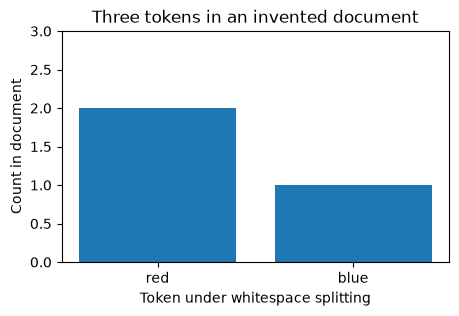

In [5]:
import matplotlib.pyplot as plt
from IPython.display import display
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(list(counts), list(counts.values()))
ax.set(xlabel='Token under whitespace splitting', ylabel='Count in document', title='Three tokens in an invented document', ylim=(0, 3))
display(fig)
plt.close(fig)

The chart shows two red tokens and one blue token. It says nothing about sentiment or semantic similarity. A frequent word can be uninformative, and two different words can have related meanings. Later NLP lessons introduce representations that address different aspects of these problems.

## 11. Realistic experiment: category normalization

Suppose a small invented survey records regions with inconsistent spaces and capitalization. Normalize a separate copy and report both the original and resulting category counts. A real data dictionary must confirm that the merged categories are intended to be equivalent.

In [6]:
regions = [' North ', 'north', 'SOUTH', 'South ', 'north']
raw_counts = Counter(regions)
clean_regions = [region.strip().casefold() for region in regions]
clean_counts = Counter(clean_regions)
print('Before:', dict(raw_counts))
print('After:', dict(clean_counts))
assert clean_counts == {'north': 3, 'south': 2}
assert sum(raw_counts.values()) == sum(clean_counts.values()) == 5

Before: {' North ': 1, 'north': 2, 'SOUTH': 1, 'South ': 1}
After: {'north': 3, 'south': 2}


The number of rows stays five while the number of distinct spellings shrinks. This is a useful reconciliation check. If a cleaning operation removes records, report that separately from merging equivalent labels. Do not confuse an absent value with a literal string such as `'None'` without an explicit format rule.

## 12. Choices and experiments

There are no trained parameters here. Choices include normalization, token boundaries, allowed categories, and empty-input behavior. Compare `.split()` with `.split(' ')` on repeated spaces: the latter can create empty strings because it splits on a specific separator rather than arbitrary whitespace runs. Such details change token counts and downstream features.

## 13. Evaluation

Test original preservation, expected transformations, count reconciliation, leading zeros, empty strings, and quoted delimiters. For a normalization function, applying it twice should often give the same result as applying it once; this property is called idempotence. Idempotence is a useful check but does not prove the transformation preserves meaning.

## 14. Assumptions and limitations

Our token example assumes whitespace-separated English words with no punctuation. Unicode text can contain combining characters and emoji sequences, so Python's string length is not always the number of visible characters a reader perceives. Case normalization, accents, and punctuation can carry meaning. A single universal “clean text” function is rarely appropriate for every dataset.

## 15. Common mistakes and debugging

Do not use `eval` to interpret untrusted text. Use a parser appropriate to the declared format. Do not remove every nondigit from an identifier or date and assume the result preserves meaning. Do not concatenate filesystem paths manually when a path library can handle separators. Use `repr` to reveal hidden whitespace when two visually similar labels fail to match.

## 16. Comparison with alternatives

Strings preserve raw text; parsed numeric values enable arithmetic; categorical values encode a finite vocabulary. A Counter gives simple counts, while pandas offers tabular string operations and joins. NLP tokenizers address more complex linguistic or subword rules. Choose the simplest representation that preserves the information relevant to the task.

## 17. Exercises

1. **Beginner:** Predict `'academy'[1:4]` and `'academy'[-1]`.
2. **Beginner:** Count tokens in `'cat dog cat cat'` and compute the relative frequency of cat.
3. **Beginner:** Explain why `'0042'` should sometimes remain text.
4. **Intermediate:** Compare whitespace splitting with splitting on a literal space for `'a  b'`.
5. **Intermediate:** Explain why normalizing all text to lowercase could damage a case-sensitive identifier system.
6. **Challenge:** Write a category-normalization function that trims whitespace, uses caseless matching, rejects unknown categories, and is idempotent for accepted inputs.

## 18. Detailed solutions

1. Positions one through three spell `'cad'`; the final character is `'y'`. The stop position four is excluded.
2. There are four tokens, three of them cat, so its relative frequency is 3/4=0.75.
3. Leading zeros may be part of an identifier's required form. Numeric conversion would produce 42 and discard them.
4. `.split()` returns `['a','b']`; `.split(' ')` returns `['a','','b']`, preserving an empty segment between consecutive separators.
5. Two distinct valid identifiers such as `Ab` and `ab` could collapse into one, causing an incorrect join or identity assignment.
6. Define the allowed vocabulary and raise a useful error for unknown values. Normalization is not permission to silently invent a category.

In [7]:
def normalize_region(value):
    normalized = value.strip().casefold()
    if normalized not in {'north', 'south'}:
        raise ValueError('Unknown region')
    return normalized

assert normalize_region(' NORTH ') == 'north'
assert normalize_region(normalize_region(' NORTH ')) == 'north'
assert 'a  b'.split(' ') == ['a', '', 'b']
assert 'academy'[1:4] == 'cad'
try:
    normalize_region('east')
except ValueError:
    print('Unknown category correctly rejected')
else:
    raise AssertionError('Unknown category accepted')

Unknown category correctly rejected


## 19. Knowledge check

**Are strings mutable?** No; transformations return new strings. **What does a slice exclude?** Its stop position. **Does split understand language?** Basic splitting follows separators, not semantics. **Why preserve raw text?** To audit transformations and recover information. **What does an encoding do?** Represents text as bytes for storage or transfer.

## 20. Interview preparation

**Normalization versus parsing?** Choosing a consistent representation versus interpreting a structured format. **Why avoid manual CSV splitting?** Quoting and delimiters interact. **Why can cleaning harm data?** It can merge distinct meanings or discard relevant information. **What is idempotence?** Reapplying a transformation does not further change its result. **How evaluate a text-processing rule?** Test declared invariants and domain examples, including malformed, empty, and ambiguous cases.

## 21. Summary and next steps

Text processing should make data consistent without erasing its meaning. Next study [lists, tuples, sets and dictionaries](../../../01_Python_Foundations/04_lists_tuples_sets_and_dictionaries.ipynb), then conditions, loops, and functions. Consult [PROGRESS.md](../../../PROGRESS.md) for exact implementation status.